   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00
Device: cpu | Data folder: /kaggle/working/ADRL_q2_outputs/mitdb
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list 

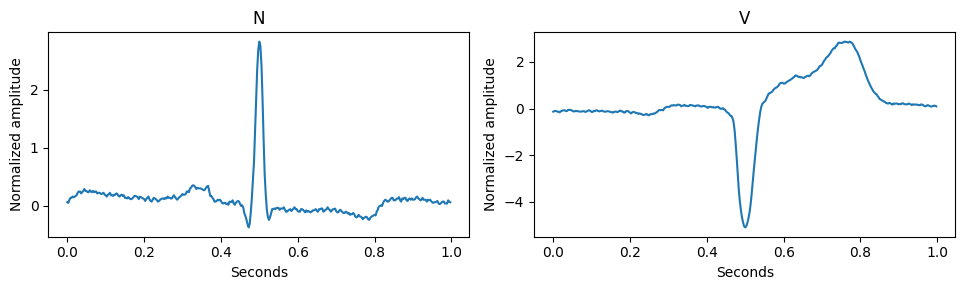

VAE epoch 01: beta=0.000, active=16, loss=94.5572
VAE epoch 02: beta=0.111, active=16, loss=14.8443
VAE epoch 03: beta=0.222, active=16, loss=13.7930
VAE epoch 04: beta=0.333, active=16, loss=15.2158
VAE epoch 05: beta=0.444, active=16, loss=16.7101
VAE epoch 06: beta=0.556, active=16, loss=17.9353
VAE epoch 07: beta=0.667, active=16, loss=18.8867
VAE epoch 08: beta=0.778, active=16, loss=19.6340
VAE epoch 09: beta=0.889, active=15, loss=20.1889
VAE epoch 10: beta=1.000, active=15, loss=20.9091
VAE epoch 11: beta=0.000, active=16, loss=2.9617
VAE epoch 12: beta=0.111, active=16, loss=6.2135
VAE epoch 13: beta=0.222, active=16, loss=8.9203
VAE epoch 14: beta=0.333, active=16, loss=10.5137
VAE epoch 15: beta=0.444, active=16, loss=12.2011
VAE epoch 16: beta=0.556, active=16, loss=13.6434
VAE epoch 17: beta=0.667, active=16, loss=14.9946
VAE epoch 18: beta=0.778, active=16, loss=16.0975
VAE epoch 19: beta=0.889, active=15, loss=17.1790
VAE epoch 20: beta=1.000, active=15, loss=18.1137
VAE

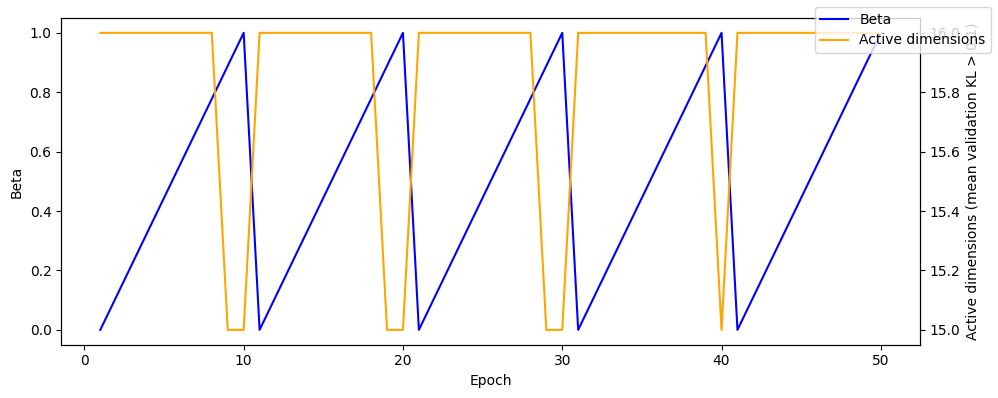

In [1]:
# Q2.1 - Cyclical beta-VAE. Run all four cells in order in Kaggle or VS Code.
# Select a Python kernel with: pip install torch numpy matplotlib wfdb ipykernel
# Papers: https://arxiv.org/abs/1312.6114
# https://openreview.net/forum?id=Sy2fzU9gl ; https://aclanthology.org/N19-1021/
# Both supplied PDFs define the task; small layer widths are implementation choices.
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import random
import json
from pathlib import Path
import sys
import subprocess
try:
    import wfdb
except ImportError:
    # Kaggle needs Internet enabled for this one-time dependency installation.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wfdb'])
    import wfdb

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 2026
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
set_seed()
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
# Use an extracted raw MIT-BIH dataset with .hea, .dat and .atr files.
# Set DATA_DIR explicitly if you attach more than one copy of the dataset.
DATA_DIR = None
ON_KAGGLE = Path('/kaggle/input').is_dir()
OUTPUT_DIR = (Path('/kaggle/working') if ON_KAGGLE else Path.cwd()) / 'ADRL_q2_outputs'
DOWNLOAD_DATA = True  # If no raw records are found, download MIT-BIH from PhysioNet.
if DATA_DIR is None:
    search_root = Path('/kaggle/input') if ON_KAGGLE else Path.cwd() / 'data' / 'mitdb'
    candidates = {}
    for header in search_root.rglob('*.hea'):
        if (header.stem.isdigit() and header.with_suffix('.dat').exists()
                and header.with_suffix('.atr').exists()):
            candidates[header.parent] = candidates.get(header.parent, 0) + 1
    folders = sorted(folder for folder, count in candidates.items() if count >= 5)
    if len(folders) > 1:
        raise ValueError(f'Multiple raw datasets found. Set DATA_DIR to one of: {folders}')
    DATA_DIR = folders[0] if folders else OUTPUT_DIR / 'mitdb'
DATA_DIR = Path(DATA_DIR)
BATCH_SIZE = 128
LATENT_DIM = 16
VAE_EPOCHS = 50  # Required: five cycles of ten epochs.
VQ_EPOCHS = 20
STARGAN_EPOCHS = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device, '| Data folder:', DATA_DIR)

record_paths = sorted(p.with_suffix('') for p in DATA_DIR.rglob('*.hea')
                      if p.with_suffix('.atr').exists() and p.with_suffix('.dat').exists())
if not record_paths and DOWNLOAD_DATA:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print('Downloading MIT-BIH from PhysioNet; this needs internet access.')
    wfdb.dl_database('mitdb', dl_dir=str(DATA_DIR))
    record_paths = sorted(p.with_suffix('') for p in DATA_DIR.rglob('*.hea')
                          if p.with_suffix('.atr').exists() and p.with_suffix('.dat').exists())
if len(record_paths) < 5:
    raise ValueError('Attach/extract raw MIT-BIH .hea/.dat/.atr files and set DATA_DIR, or set DOWNLOAD_DATA=True with Internet enabled.')

# Split whole records so beats from a record do not enter both sets.
rng = np.random.default_rng(SEED)
order = rng.permutation(len(record_paths))
cut = int(0.8 * len(record_paths))
train_records = sorted(record_paths[i] for i in order[:cut])
val_records = sorted(record_paths[i] for i in order[cut:])

def read_beats(records):
    beats, labels, metadata = [], [], []
    for path in records:
        record = wfdb.rdrecord(str(path))
        annotation = wfdb.rdann(str(path), 'atr')
        if record.fs != 360:
            raise ValueError(f'{path}: expected a 360 Hz MIT-BIH recording.')
        channel = record.sig_name.index('MLII') if 'MLII' in record.sig_name else 0
        signal = record.p_signal[:, channel]
        for location, symbol in zip(annotation.sample, annotation.symbol):
            if symbol not in ('N', 'V') or location < 180 or location + 180 > len(signal):
                continue
            beat = signal[location - 180:location + 180].astype(np.float32)
            if not np.isfinite(beat).all():
                raise ValueError(f'{path}: nonfinite ECG window.')
            beats.append(beat)
            labels.append(0 if symbol == 'N' else 1)
            metadata.append(dict(record=path.name, sample=int(location),
                                 label=symbol, channel=record.sig_name[channel]))
    if not beats:
        raise ValueError('No N/V beats found in these records.')
    # Define the order BEFORE training: N first, then V; record and time within each class.
    # This makes the literal validation index 150 an N when enough N beats exist.
    indices = sorted(range(len(beats)), key=lambda i: (labels[i], metadata[i]['record'], metadata[i]['sample']))
    return (np.stack([beats[i] for i in indices]), np.array([labels[i] for i in indices]),
            [metadata[i] for i in indices])

train_x, train_y, train_meta = read_beats(train_records)
val_x, val_y, val_meta = read_beats(val_records)
mean_train = float(train_x.astype(np.float64).mean())
std_train = float(train_x.astype(np.float64).std())
if std_train <= 0:
    raise ValueError('Training ECG has zero variance.')
train_x = ((train_x - mean_train) / std_train).astype(np.float32)
val_x = ((val_x - mean_train) / std_train).astype(np.float32)

class ECGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = torch.from_numpy(signals).unsqueeze(1)
        self.labels = torch.from_numpy(labels).long()
    def __len__(self):
        return len(self.signals)
    def __getitem__(self, index):
        return self.signals[index], self.labels[index]

train_data = ECGDataset(train_x, train_y)
val_data = ECGDataset(val_x, val_y)
assert len(val_data) > 150 and val_y[150] == 0, 'Need at least 151 N validation beats.'
assert set(train_y.tolist()) == {0, 1} and set(val_y.tolist()) == {0, 1}
def make_train_loader():
    return DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=device.type == 'cuda',
                      generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=device.type == 'cuda',
                        generator=torch.Generator().manual_seed(SEED))
audit = dict(seed=SEED, train_mean=mean_train, train_std=std_train,
             train_records=[str(p) for p in train_records], val_records=[str(p) for p in val_records],
             validation_order='label, record, annotation sample', validation_metadata=val_meta,
             sample_100=val_meta[99], index_150=val_meta[150], torch_version=torch.__version__,
             device=str(device), gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else None)
(OUTPUT_DIR / 'data_audit.json').write_text(json.dumps(audit, indent=2))
print('Train/validation:', len(train_data), len(val_data))
print('100th sample:', val_meta[99], '| index 150:', val_meta[150])
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for label, ax in enumerate(axes):
    index = int(np.flatnonzero(train_y == label)[0])
    ax.plot(np.arange(360) / 360, train_x[index])
    ax.set(title=['N', 'V'][label], xlabel='Seconds', ylabel='Normalized amplitude')
plt.tight_layout()
plt.show()

results = {}
def save_results():
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))

def take_step(loss, optimizer, model):
    if not torch.isfinite(loss).item():
        raise FloatingPointError('Nonfinite loss; training stopped.')
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    parameters = [p for p in model.parameters() if p.requires_grad]
    if any(p.grad is None for p in parameters):
        raise FloatingPointError('Missing gradient.')
    if not torch.stack([torch.isfinite(p.grad).all() for p in parameters]).all().item():
        raise FloatingPointError('Nonfinite gradient.')
    optimizer.step()

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(16, 32, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(32, 64, 4, 2, 1), nn.ReLU())
        self.mu = nn.Linear(64 * 45, LATENT_DIM)
        self.logvar = nn.Linear(64 * 45, LATENT_DIM)
        self.expand = nn.Linear(LATENT_DIM, 64 * 45)
        self.decoder = nn.Sequential(nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(16, 1, 4, 2, 1))
    def encode(self, x):
        hidden = self.encoder(x).flatten(1)
        return self.mu(hidden), self.logvar(hidden)
    def decode(self, z):
        return self.decoder(self.expand(z).reshape(-1, 64, 45))
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

def kl_per_dimension(mu, logvar):
    return 0.5 * (mu.square() + logvar.exp() - 1 - logvar)

set_seed()
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
train_loader = make_train_loader()
probe_epsilon = torch.randn(1, LATENT_DIM, generator=torch.Generator().manual_seed(SEED)).to(device)
probe_x = val_data[99][0].unsqueeze(0).to(device)
beta_history, active_history, vae_losses = [], [], []
probe_latents = {}
assert VAE_EPOCHS == 50
for epoch in range(1, VAE_EPOCHS + 1):
    beta = ((epoch - 1) % 10) / 9
    vae.train()
    total = 0.0
    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        reconstructed, mu, logvar = vae(x)
        # Gaussian reconstruction (unit variance): half summed squared error per beat.
        reconstruction_loss = 0.5 * (reconstructed - x).square().sum(dim=(1, 2)).mean()
        kl_loss = kl_per_dimension(mu, logvar).sum(dim=1).mean()
        loss = reconstruction_loss + beta * kl_loss
        take_step(loss, optimizer, vae)
        total += loss.item() * len(x)
    vae.eval()
    kl_sum = torch.zeros(LATENT_DIM, dtype=torch.float64)
    with torch.no_grad():
        for x, _ in val_loader:
            mu, logvar = vae.encode(x.to(device, non_blocking=True))
            kl_sum += kl_per_dimension(mu, logvar).double().cpu().sum(0)
        active = int((kl_sum / len(val_data) > 0.1).sum())
        if epoch in (10, 11):
            mu, logvar = vae.encode(probe_x)
            probe_latents[epoch] = (mu + torch.exp(0.5 * logvar) * probe_epsilon).cpu().clone()
    beta_history.append(beta)
    active_history.append(active)
    vae_losses.append(total / len(train_data))
    print(f'VAE epoch {epoch:02d}: beta={beta:.3f}, active={active}, loss={vae_losses[-1]:.4f}')

z10, z11 = probe_latents[10].double().flatten(), probe_latents[11].double().flatten()
denominator = z10.square().sum().sqrt() * z11.square().sum().sqrt()
if denominator.item() == 0:
    raise ValueError('Cosine similarity is undefined for a zero latent vector.')
results['q2_1_cosine_similarity'] = ((z10 * z11).sum() / denominator).item()
torch.save(dict(model=vae.state_dict(), z_epoch10=probe_latents[10], z_epoch11=probe_latents[11],
                probe_epsilon=probe_epsilon.cpu(), beta=beta_history, active=active_history,
                loss=vae_losses), OUTPUT_DIR / 'q2_1_vae.pt')
save_results()
print('Q2.1 cosine similarity:', repr(results['q2_1_cosine_similarity']))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 51), beta_history, color='blue', label='Beta')
ax.set(xlabel='Epoch', ylabel='Beta')
other = ax.twinx()
other.plot(range(1, 51), active_history, color='orange', label='Active dimensions')
other.set_ylabel('Active dimensions (mean validation KL > 0.1)')
fig.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_1_beta_activity.png')
plt.show()

q21_complete = True


Q2.2 dimension: 0 | variance: 0.9790308768067651
Selected dimension passes KL > 0.1: True


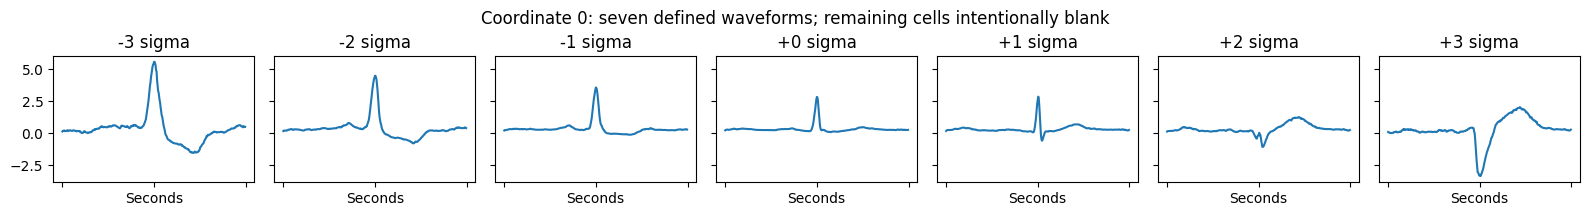

Peak-to-peak amplitudes: [7.095873832702637, 5.263965606689453, 3.6772499084472656, 2.7396926879882812, 3.4273226261138916, 2.329420566558838, 5.35367488861084]
Peak locations (sample indices): [181, 180, 180, 180, 181, 259, 259]
Inspect changes in height, timing and width. These measurements alone do not establish a physiological meaning.


In [2]:
# Run cell 1 first. This cell analyzes its trained VAE.
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.2 - Latent traversal. Reuse the trained VAE from cell 1; no new model training.
# Source: beta-VAE, https://openreview.net/forum?id=Sy2fzU9gl, and GUIDE.pdf.
vae.eval()
vae.requires_grad_(False)
all_means, all_kl = [], []
with torch.no_grad():
    for x, _ in val_loader:
        mu, logvar = vae.encode(x.to(device, non_blocking=True))
        all_means.append(mu.double().cpu())
        all_kl.append(kl_per_dimension(mu, logvar).double().cpu())
embeddings = torch.cat(all_means)
latent_mean = embeddings.mean(0)
latent_variance = (embeddings - latent_mean).square().mean(0)  # Divide by N.
active_mask = torch.cat(all_kl).mean(0) > 0.1
dimension = int(latent_variance.argmax())
sigma = latent_variance[dimension].sqrt()
sweep = torch.arange(-3, 4, dtype=torch.float64) * sigma
z = latent_mean.repeat(7, 1)  # Fix every other dimension, including inactive ones.
z[:, dimension] = sweep  # Exactly -3 sigma to +3 sigma, not mean +/- 3 sigma.
with torch.no_grad():
    waveforms = vae.decode(z.float().to(device)).cpu()
results['q2_2_max_variance_dim_index'] = dimension
results['q2_2_max_variance_value'] = latent_variance[dimension].item()
save_results()
torch.save(dict(variance=latent_variance, mean=latent_mean, active_mask=active_mask,
                sweep=sweep, z=z, waveforms=waveforms), OUTPUT_DIR / 'q2_2_traversal.pt')
print('Q2.2 dimension:', dimension, '| variance:', repr(latent_variance[dimension].item()))
print('Selected dimension passes KL > 0.1:', bool(active_mask[dimension]))

# The PDFs specify seven waveforms AND a 7x7 canvas. Follow the guide: first row only.
fig, axes = plt.subplots(7, 7, figsize=(16, 12), sharex=True, sharey=True)
for ax in axes.flat:
    ax.set_visible(False)
for i in range(7):
    ax = axes[0, i]
    ax.set_visible(True)
    ax.plot(np.arange(360) / 360, waveforms[i, 0].numpy())
    ax.set_title(f'{i - 3:+d} sigma')
    ax.set_xlabel('Seconds')
fig.suptitle(f'Coordinate {dimension}: seven defined waveforms; remaining cells intentionally blank')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_2_traversal.png')
plt.show()
amplitude_range = waveforms[:, 0].amax(1) - waveforms[:, 0].amin(1)
print('Peak-to-peak amplitudes:', amplitude_range.tolist())
print('Peak locations (sample indices):', waveforms[:, 0].argmax(1).tolist())
print('Inspect changes in height, timing and width. These measurements alone do not establish a physiological meaning.')
# Add your observation after looking at the actual plot; no morphology is assumed in advance.
MORPHOLOGY_OBSERVATION = ''
if MORPHOLOGY_OBSERVATION:
    (OUTPUT_DIR / 'q2_2_observation.txt').write_text(MORPHOLOGY_OBSERVATION)


In [3]:
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.3 - Spherical VQ-VAE.
# Paper: https://arxiv.org/abs/1711.00937, sections 3.1-3.2 and Appendix A.1.
# Cosine lookup and unit-sphere EMA are assignment modifications to the original VQ-VAE.
# GUIDE interpretation: STE sends gradients to the ENCODER only. The codebook is a buffer.

def unit_vectors(x):
    norm = torch.linalg.vector_norm(x, dim=-1, keepdim=True)
    fallback = torch.zeros_like(x)
    fallback[..., 0] = 1
    return torch.where(norm > 1e-8, x / norm.clamp_min(1e-8), fallback)

class SphericalVQVAE(nn.Module):
    def __init__(self, code_count=64, code_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(16, 32, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(32, code_dim, 4, 2, 1))
        self.decoder = nn.Sequential(nn.ConvTranspose1d(code_dim, 32, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(16, 1, 4, 2, 1))
        codes = unit_vectors(torch.randn(code_count, code_dim))
        self.register_buffer('codebook', codes)
        self.register_buffer('ema_count', torch.ones(code_count))
        self.register_buffer('ema_sum', codes.clone())
        self.register_buffer('unused_steps', torch.zeros(code_count, dtype=torch.long))
        self.decay = 0.99
        self.patience = 100

    def forward(self, x):
        encoded = self.encoder(x).transpose(1, 2)  # [B,45,32]
        normalized = unit_vectors(encoded)
        flat = normalized.reshape(-1, normalized.shape[-1])
        similarities = flat @ self.codebook.T
        indices = similarities.argmax(dim=1)
        quantized = self.codebook[indices].reshape_as(normalized)
        commitment = (normalized - quantized.detach()).square().mean()
        # Forward value is the selected code; backward derivative goes only to normalized.
        encoder_path = normalized + (quantized - normalized).detach()
        reconstructed = self.decoder(encoder_path.transpose(1, 2))
        return reconstructed, commitment, flat.detach(), indices.detach()

    @torch.no_grad()
    def update_codebook(self, flat, indices):
        assignments = (indices[:, None] == torch.arange(len(self.codebook), device=indices.device)).float()
        counts = assignments.sum(0)
        sums = assignments.T @ flat
        self.ema_count.mul_(self.decay).add_(counts, alpha=1 - self.decay)
        self.ema_sum.mul_(self.decay).add_(sums, alpha=1 - self.decay)
        centroids = self.ema_sum / (self.ema_count[:, None] + 1e-8)
        self.codebook.copy_(unit_vectors(centroids))
        self.unused_steps.add_(1)
        self.unused_steps[counts > 0] = 0
        dead = self.unused_steps >= self.patience
        if dead.any():
            selected = torch.randint(len(flat), (int(dead.sum()),), device=flat.device)
            replacements = unit_vectors(flat[selected])
            self.codebook[dead] = replacements
            self.ema_count[dead] = 1
            self.ema_sum[dead] = replacements
            self.unused_steps[dead] = 0
        assert torch.allclose(self.codebook.square().sum(1), torch.ones_like(self.ema_count), atol=1e-5)

set_seed()
vqvae = SphericalVQVAE().to(device)
optimizer_vq = torch.optim.Adam(vqvae.parameters(), lr=0.001)
assert 'codebook' not in dict(vqvae.named_parameters())
vq_loader = make_train_loader()
vq_history = []
for epoch in range(1, VQ_EPOCHS + 1):
    vqvae.train()
    total = 0.0
    for x, _ in vq_loader:
        x = x.to(device, non_blocking=True)
        reconstructed, commitment, flat, indices = vqvae(x)
        reconstruction_loss = (reconstructed - x).square().mean()
        loss = reconstruction_loss + 0.25 * commitment
        take_step(loss, optimizer_vq, vqvae)
        vqvae.update_codebook(flat, indices)  # No optimizer gradient updates these vectors.
        total += loss.item() * len(x)
    vq_history.append(total / len(train_data))
    if epoch == 1:
        codes = unit_vectors(vqvae.codebook.detach().cpu().double())
        cosine_matrix = codes @ codes.T
        off_diagonal = ~torch.eye(len(codes), dtype=torch.bool)
        maximum_cosine = cosine_matrix[off_diagonal].max().item()
        results['q2_3_max_offdiag_cosine_epoch1'] = maximum_cosine
        torch.save(dict(codebook=codes, cosine_matrix=cosine_matrix), OUTPUT_DIR / 'q2_3_epoch1_codes.pt')
        save_results()
        print('Q2.3 epoch-1 maximum off-diagonal cosine:', repr(maximum_cosine))
    print(f'VQ-VAE epoch {epoch}: loss={vq_history[-1]:.6f}')
torch.save(dict(model=vqvae.state_dict(), losses=vq_history), OUTPUT_DIR / 'q2_3_vqvae.pt')

Q2.3 epoch-1 maximum off-diagonal cosine: 0.9968832157217792
VQ-VAE epoch 1: loss=0.141559
VQ-VAE epoch 2: loss=0.026539
VQ-VAE epoch 3: loss=0.022973
VQ-VAE epoch 4: loss=0.024352
VQ-VAE epoch 5: loss=0.020918
VQ-VAE epoch 6: loss=0.019079
VQ-VAE epoch 7: loss=0.022252
VQ-VAE epoch 8: loss=0.019995
VQ-VAE epoch 9: loss=0.019385
VQ-VAE epoch 10: loss=0.019819
VQ-VAE epoch 11: loss=0.019778
VQ-VAE epoch 12: loss=0.019909
VQ-VAE epoch 13: loss=0.020444
VQ-VAE epoch 14: loss=0.022134
VQ-VAE epoch 15: loss=0.020787
VQ-VAE epoch 16: loss=0.021302
VQ-VAE epoch 17: loss=0.022223
VQ-VAE epoch 18: loss=0.021883
VQ-VAE epoch 19: loss=0.021268
VQ-VAE epoch 20: loss=0.022549


StarGAN epoch 1: D=1.5629, G=3.9821
StarGAN epoch 2: D=1.4372, G=3.5108
StarGAN epoch 3: D=1.4401, G=3.4450
StarGAN epoch 4: D=1.3957, G=3.4192
StarGAN epoch 5: D=1.3619, G=3.4333
StarGAN epoch 6: D=1.3253, G=3.4277
StarGAN epoch 7: D=1.2596, G=3.3898
StarGAN epoch 8: D=1.2002, G=3.3751
StarGAN epoch 9: D=1.1711, G=3.3960
StarGAN epoch 10: D=1.1444, G=3.3895
StarGAN epoch 11: D=1.1252, G=3.3842
StarGAN epoch 12: D=1.1078, G=3.3949
StarGAN epoch 13: D=1.0855, G=3.3638
StarGAN epoch 14: D=1.0704, G=3.2990
StarGAN epoch 15: D=1.0500, G=3.2830
StarGAN epoch 16: D=1.0189, G=3.2558
StarGAN epoch 17: D=0.9905, G=3.2376
StarGAN epoch 18: D=0.9817, G=3.2495
StarGAN epoch 19: D=0.9759, G=3.2590
StarGAN epoch 20: D=0.9678, G=3.2610


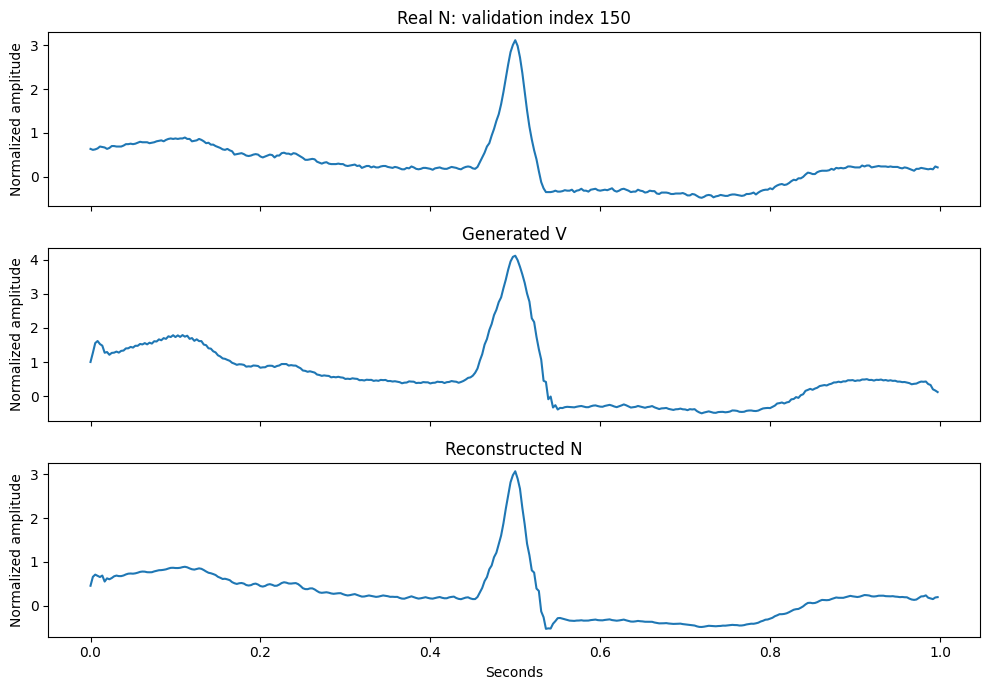

Q2.4 maximum amplitude (normalized units): 4.110568523406982
The same maximum in original signal units: 1.5339494828098736
{
  "q2_1_cosine_similarity": 0.8071993089835765,
  "q2_2_max_variance_dim_index": 0,
  "q2_2_max_variance_value": 0.9790308768067651,
  "q2_3_max_offdiag_cosine_epoch1": 0.9968832157217792,
  "q2_4_generated_v_max_amplitude_val150": 4.110568523406982
}
Saved results in: /kaggle/working/ADRL_q2_outputs


In [4]:
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.4 - StarGAN-1D: exactly one generator and one discriminator for both directions.
# Paper: https://arxiv.org/abs/1711.09020, section 3.1.
# Follow the GUIDE's simple logistic/BCE objective; not the paper's WGAN-GP experiments.
# lambda_cls=1 and lambda_cycle=10; linear waveform output because inputs are standardized.

class StarGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(3, 32, 7, padding=3), nn.ReLU(),
                                 nn.Conv1d(32, 64, 4, 2, 1), nn.ReLU(),
                                 nn.Conv1d(64, 64, 3, padding=1), nn.ReLU(),
                                 nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.ReLU(),
                                 nn.Conv1d(32, 1, 7, padding=3))
    def forward(self, x, target):
        one_hot = (target[:, None] == torch.arange(2, device=x.device)).float()
        labels = one_hot[:, :, None].expand(-1, -1, x.shape[-1])
        return self.net(torch.cat([x, labels], dim=1))

class StarDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.LeakyReLU(0.2),
                                      nn.Conv1d(16, 32, 4, 2, 1), nn.LeakyReLU(0.2),
                                      nn.Conv1d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2))
        self.source = nn.Linear(64, 1)
        self.domain = nn.Linear(64, 2)
    def forward(self, x):
        features = self.features(x).mean(dim=2)
        return self.source(features).squeeze(1), self.domain(features)

def binary_loss(logits, targets):
    # Stable BCE with logits: log(1+exp(logit)) - target*logit.
    return (torch.logaddexp(torch.zeros_like(logits), logits) - targets * logits).mean()

def classification_loss(logits, labels):
    correct_logits = logits.gather(1, labels[:, None]).squeeze(1)
    return (torch.logsumexp(logits, dim=1) - correct_logits).mean()

set_seed()
star_g = StarGenerator().to(device)
star_d = StarDiscriminator().to(device)
optimizer_g = torch.optim.Adam(star_g.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_d = torch.optim.Adam(star_d.parameters(), lr=0.0002, betas=(0.5, 0.999))
star_loader = make_train_loader()
star_history = []
for epoch in range(1, STARGAN_EPOCHS + 1):
    star_g.train()
    star_d.train()
    total_d, total_g = 0.0, 0.0
    for x, source in star_loader:
        x, source = x.to(device, non_blocking=True), source.to(device)
        target = 1 - source
        with torch.no_grad():
            fake = star_g(x, target)
        real_logits, real_domains = star_d(x)
        fake_logits, _ = star_d(fake)
        loss_d = (binary_loss(real_logits, torch.ones_like(real_logits))
                  + binary_loss(fake_logits, torch.zeros_like(fake_logits))
                  + classification_loss(real_domains, source))
        take_step(loss_d, optimizer_d, star_d)
        optimizer_d.zero_grad(set_to_none=True)

        star_d.requires_grad_(False)
        try:
            fake = star_g(x, target)
            fake_logits, fake_domains = star_d(fake)
            reconstructed = star_g(fake, source)
            cycle_loss = (reconstructed - x).abs().mean()
            loss_g = (binary_loss(fake_logits, torch.ones_like(fake_logits))
                      + classification_loss(fake_domains, target) + 10 * cycle_loss)
            take_step(loss_g, optimizer_g, star_g)
        finally:
            star_d.requires_grad_(True)
        total_d += loss_d.item() * len(x)
        total_g += loss_g.item() * len(x)
    star_history.append([total_d / len(train_data), total_g / len(train_data)])
    print(f'StarGAN epoch {epoch}: D={star_history[-1][0]:.4f}, G={star_history[-1][1]:.4f}')

star_g.eval()
star_d.eval()
star_g.requires_grad_(False)
star_d.requires_grad_(False)
normal, label = val_data[150]  # Literal index 150 in the frozen validation order.
assert int(label) == 0, 'Validation index 150 must be N; do not substitute another sample.'
with torch.no_grad():
    normal = normal.unsqueeze(0).to(device)
    generated_v = star_g(normal, torch.ones(1, dtype=torch.long, device=device))
    reconstructed_n = star_g(generated_v, torch.zeros(1, dtype=torch.long, device=device))
maximum = generated_v.max().item()  # Literal maximum, not absolute maximum.
results['q2_4_generated_v_max_amplitude_val150'] = maximum
save_results()
torch.save(dict(generator=star_g.state_dict(), discriminator=star_d.state_dict(),
                normal=normal.cpu(), generated_v=generated_v.cpu(), reconstructed_n=reconstructed_n.cpu(),
                validation_metadata=val_meta[150], losses=star_history), OUTPUT_DIR / 'q2_4_stargan.pt')
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, signal, title in zip(axes, [normal, generated_v, reconstructed_n],
                             ['Real N: validation index 150', 'Generated V', 'Reconstructed N']):
    ax.plot(np.arange(360) / 360, signal[0, 0].cpu().numpy())
    ax.set(title=title, ylabel='Normalized amplitude')
axes[-1].set_xlabel('Seconds')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_4_N_V_N.png')
plt.show()
print('Q2.4 maximum amplitude (normalized units):', repr(maximum))
print('The same maximum in original signal units:', repr(maximum * std_train + mean_train))
required = ['q2_1_cosine_similarity', 'q2_2_max_variance_dim_index', 'q2_2_max_variance_value',
            'q2_3_max_offdiag_cosine_epoch1', 'q2_4_generated_v_max_amplitude_val150']
assert all(key in results and np.isfinite(results[key]) for key in required)
print(json.dumps(results, indent=2))
print('Saved results in:', OUTPUT_DIR)
